<a href="https://colab.research.google.com/github/Deekshita-G/General_Needs_Classification/blob/main/trail_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers librosa torch scikit-learn


Importing libraries
• os : Used to access and manage audio files and folders.
• numpy : Used for numerical operations and feature storage.
• librosa : Used to load and process audio signals.
• torch : Used to handle tensors and run deep learning models.
• AutoProcessor : Converts raw audio into model-ready input format.
• ASTModel : Extracts deep audio features from cry sounds.
• train_test_split : Splits data into training and testing sets.
• LogisticRegression : Classifies cry types using extracted features.
• classification_report : Shows precision, recall, and F1-score.
• accuracy_score : Calculates overall model accuracy.

In [ ]:
import os
import numpy as np
import librosa
import torch

from transformers import AutoProcessor, ASTModel
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


unzipping the file

In [ ]:
!unzip /content/general_needs.zip -d /content/general_needs

Archive:  /content/general_needs.zip
   creating: /content/general_needs/general_needs/
   creating: /content/general_needs/general_needs/donateacry-corpus-master/
   creating: /content/general_needs/general_needs/donateacry-corpus-master/donateacry-android-upload-bucket/
  inflating: /content/general_needs/general_needs/donateacry-corpus-master/donateacry-android-upload-bucket/006dbee7-715a-46ee-b592-1c4e7affb788-1430218353124-1.7-f-26-hu.3gp  
  inflating: /content/general_needs/general_needs/donateacry-corpus-master/donateacry-android-upload-bucket/01a592eb-513d-4431-b7ba-b0fba5a00908-1430339263195-1.7-m-04-hu.3gp  
  inflating: /content/general_needs/general_needs/donateacry-corpus-master/donateacry-android-upload-bucket/02c3b725-26e4-4a2c-9336-04ddc58836d9-1430726196216-1.7-m-04-hu.3gp  
  inflating: /content/general_needs/general_needs/donateacry-corpus-master/donateacry-android-upload-bucket/02ead89b-aa02-453e-8b83-6ebde9fe7551-1430233132879-1.7-m-26-hu.3gp  
  inflating: /conte

The code reads the dataset folder, identifies all subfolders as class labels, assigns each label a numeric ID, creates mappings between labels and IDs, counts the total classes, and prints the labels, their IDs, and the total number of classes.

In [ ]:
!ls /content/general_needs

general_needs


In [ ]:
!find /content/general_needs -maxdepth 3 -type d

/content/general_needs
/content/general_needs/general_needs
/content/general_needs/general_needs/donateacry-corpus-master
/content/general_needs/general_needs/donateacry-corpus-master/donateacry-ios-upload-bucket
/content/general_needs/general_needs/donateacry-corpus-master/donateacry-android-upload-bucket
/content/general_needs/general_needs/donateacry-corpus-master/donateacry_corpus_cleaned_and_updated_data


In [ ]:
!ls /content/general_needs/general_needs/donateacry-corpus-master/donateacry_corpus_cleaned_and_updated_data

belly_pain  burping  discomfort  hungry  README.md  tired


In [ ]:
DATASET_PATH = "/content/general_needs/general_needs/donateacry-corpus-master/donateacry_corpus_cleaned_and_updated_data"

labels = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

num_labels = len(labels)

print("Labels:", labels)
print("Label to ID:", label2id)
print("Number of labels:", num_labels)


Labels: ['belly_pain', 'burping', 'discomfort', 'hungry', 'tired']
Label to ID: {'belly_pain': 0, 'burping': 1, 'discomfort': 2, 'hungry': 3, 'tired': 4}
Number of labels: 5


Loads a pretrained Audio Spectrogram Transformer (AST) model and its processor, sets the device to GPU if available, moves the model to the device, and switches it to evaluation mode for feature extraction or inference.

In [ ]:
processor = AutoProcessor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ast_model = ASTModel.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
).to(device)

ast_model.eval()   # inference mode


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ASTModel(
  (embeddings): ASTEmbeddings(
    (patch_embeddings): ASTPatchEmbeddings(
      (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ASTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ASTLayer(
        (attention): ASTAttention(
          (attention): ASTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ASTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ASTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ASTOutput(
          (d

Loads an audio file, processes it with the AST processor, extracts deep audio features using the AST model, applies mean pooling to get a fixed-length embedding, and returns a 768-dimensional feature vector.

In [ ]:
def extract_ast_features(audio_path):
    audio, sr = librosa.load(audio_path, sr=16000, mono=True)

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    # Move inputs to same device as model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = ast_model(**inputs)

    # Mean pooling over time dimension
    embedding = outputs.last_hidden_state.mean(dim=1)  # (1, 768)

    return embedding[0].cpu().numpy()  # always (768,)


Iterates over all audio files in each class folder, extracts AST features for each .wav file, validates the feature shape, stores valid features in X and their label IDs in y, counts any skipped files, and finally converts X and y to arrays while printing their shapes and the number of skipped files.

In [ ]:
X = []
y = []

expected_dim = 768
skipped = 0

for label in labels:
    folder = os.path.join(DATASET_PATH, label)

    for file in os.listdir(folder):
        if not file.lower().endswith(".wav"):
            continue

        path = os.path.join(folder, file)

        try:
            features = extract_ast_features(path)

            # Shape validation (CRITICAL)
            if features.shape != (expected_dim,):
                skipped += 1
                continue

            X.append(features)
            y.append(label2id[label])

        except Exception as e:
            skipped += 1
            continue

X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)   # (N, 768)
print("Labels shape:", y.shape)            # (N,)
print("Skipped files:", skipped)


Feature matrix shape: (457, 768)
Labels shape: (457,)
Skipped files: 0


Splits the dataset into training (80%) and testing (20%) sets while keeping the class distribution balanced using stratification.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Counts and prints how many samples belong to each class in the dataset to check class distribution.

In [ ]:
from collections import Counter
print("Label distribution in dataset:", Counter(y))


Label distribution in dataset: Counter({np.int64(3): 382, np.int64(2): 27, np.int64(4): 24, np.int64(0): 16, np.int64(1): 8})


Initializes a Logistic Regression classifier with balanced class weights, trains it on the training data (X_train, y_train) to learn to classify cry types.

Classes: ['belly_pain', 'burping', 'discomfort', 'hungry', 'tired']


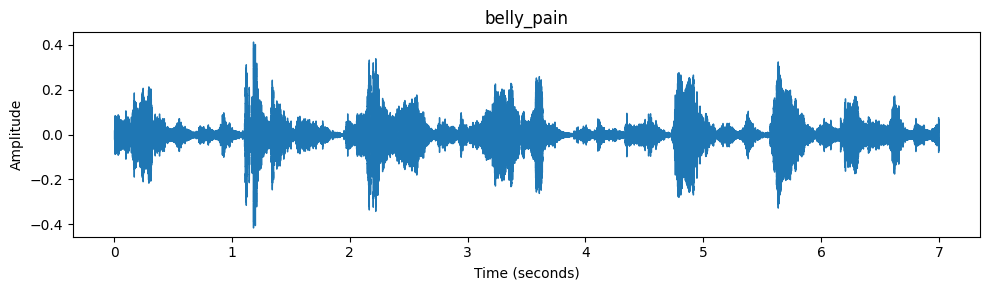

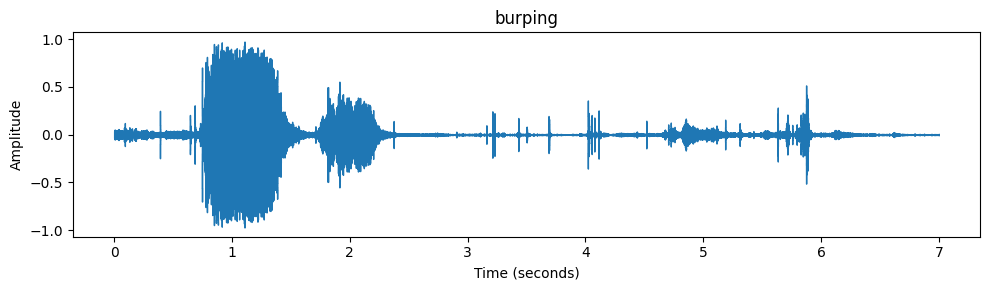

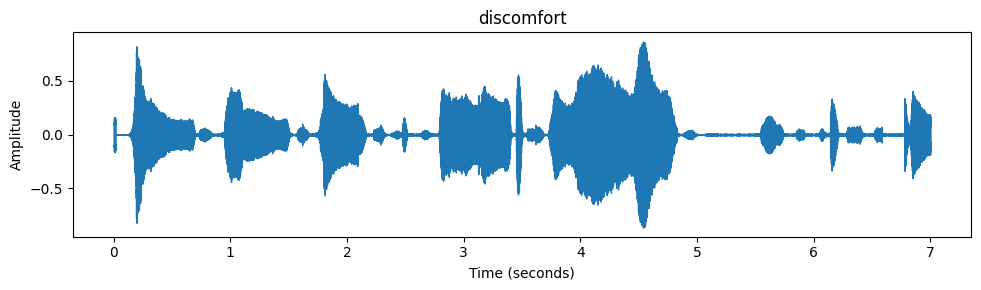

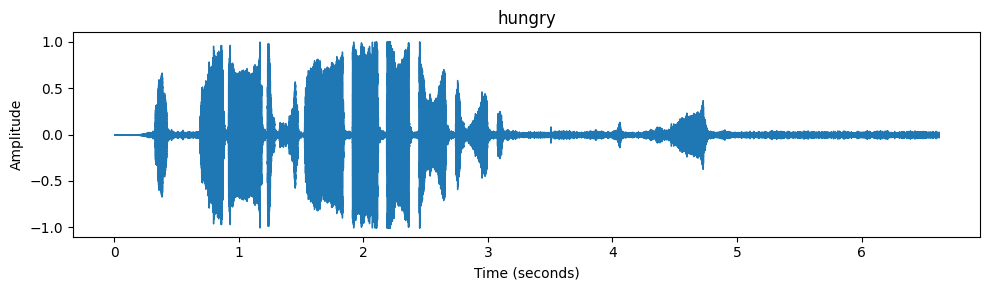

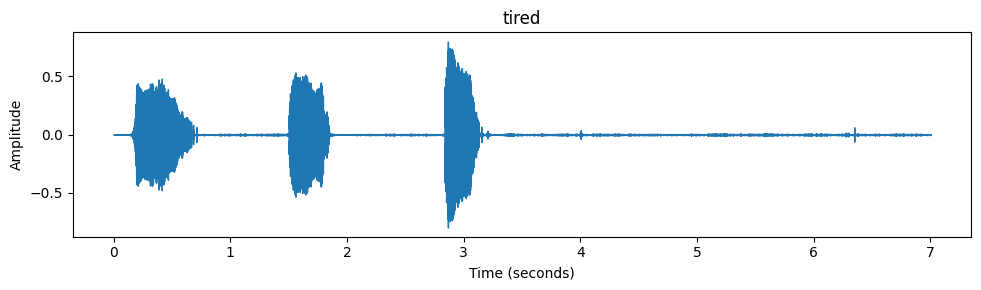

In [ ]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random

DATASET_PATH = "/content/general_needs/general_needs/donateacry-corpus-master/donateacry_corpus_cleaned_and_updated_data"

labels = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

print("Classes:", labels)

for label in labels:
    class_path = os.path.join(DATASET_PATH, label)

    # pick one random audio file from the class
    files = [f for f in os.listdir(class_path) if f.endswith(".wav")]
    if not files:
        continue
    file_path = os.path.join(class_path, random.choice(files))

    # load audio
    y, sr = librosa.load(file_path, sr=None)

    # plot waveform
    plt.figure(figsize=(10, 3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(label)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

Classes: ['belly_pain', 'burping', 'discomfort', 'hungry', 'tired']


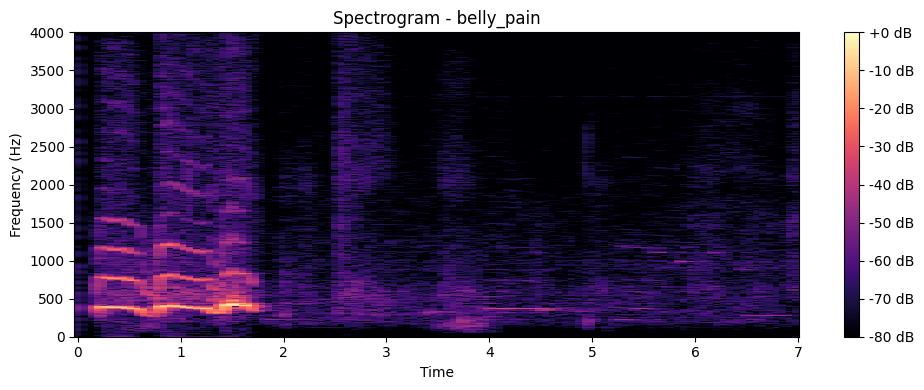

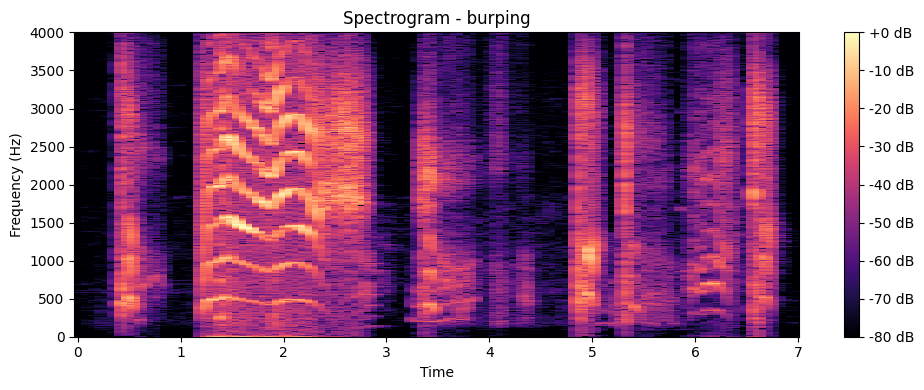

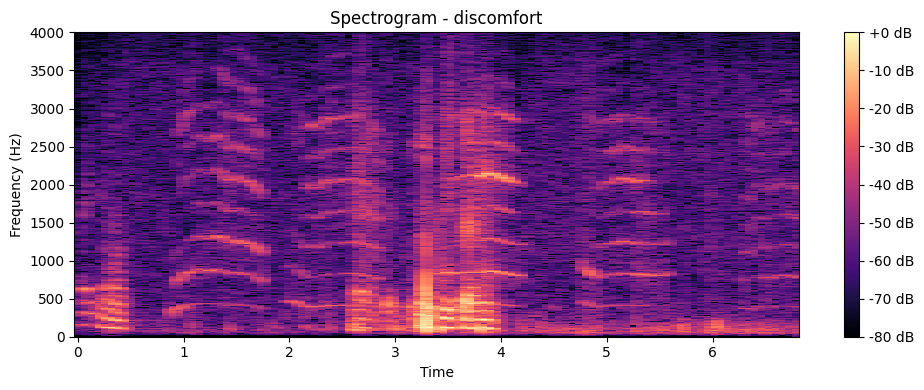

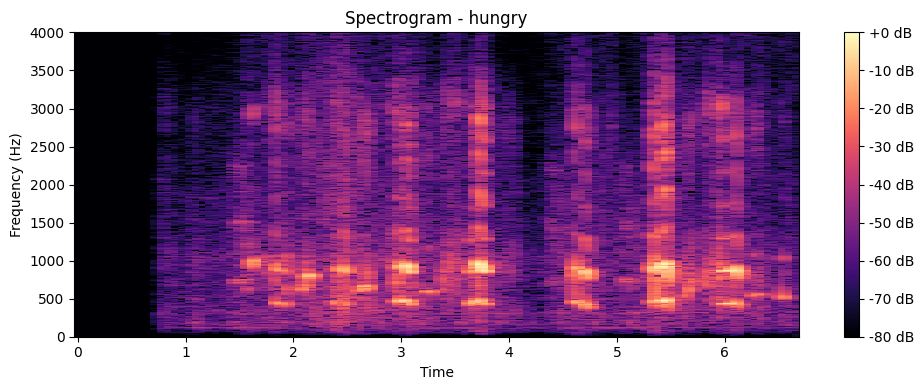

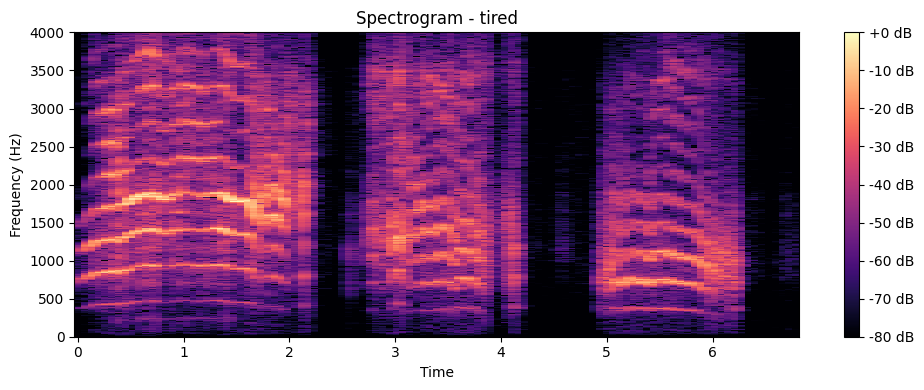

In [ ]:
import os
import random
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

DATASET_PATH = "/content/general_needs/general_needs/donateacry-corpus-master/donateacry_corpus_cleaned_and_updated_data"

labels = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

print("Classes:", labels)

for label in labels:
    class_path = os.path.join(DATASET_PATH, label)

    # pick one random file from the class
    files = [f for f in os.listdir(class_path) if f.endswith(".wav")]
    if not files:
        continue
    file_path = os.path.join(class_path, random.choice(files))

    # load audio
    y, sr = librosa.load(file_path, sr=None)

    # compute spectrogram
    D = np.abs(librosa.stft(y))
    DB = librosa.amplitude_to_db(D, ref=np.max)

    # plot spectrogram
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(DB, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Spectrogram - {label}")
    plt.xlabel("Time")
    plt.ylabel("Frequency (Hz)")
    plt.tight_layout()
    plt.show()

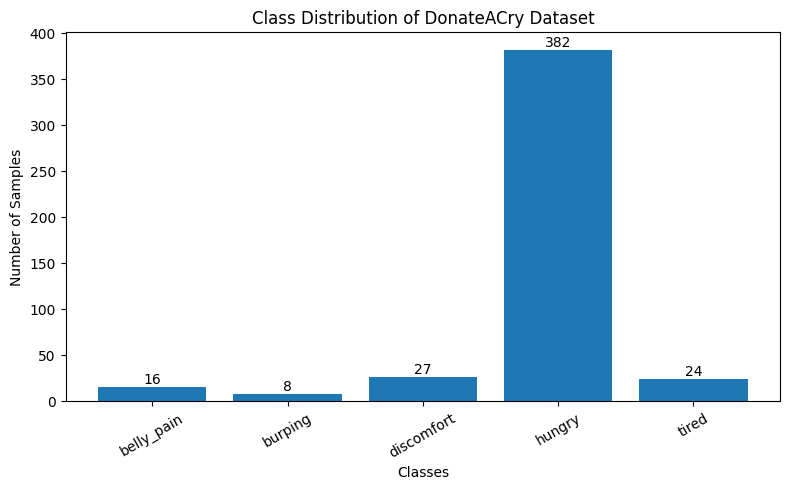

In [ ]:
import os
import matplotlib.pyplot as plt

DATASET_PATH = "/content/general_needs/general_needs/donateacry-corpus-master/donateacry_corpus_cleaned_and_updated_data"

labels = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

counts = []

for label in labels:
    class_path = os.path.join(DATASET_PATH, label)
    num_files = len([f for f in os.listdir(class_path) if f.endswith(".wav")])
    counts.append(num_files)

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(labels, counts)

# add numbers on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:,}', ha='center', va='bottom')

plt.title("Class Distribution of DonateACry Dataset")
plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver='lbfgs',
    multi_class='multinomial'
)

classifier.fit(X_train, y_train)   # THIS MUST RUN BEFORE PREDICT


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial')

Uses the trained classifier to predict labels on the test set, prints overall accuracy, and shows precision, recall, and F1-score for each class.

In [ ]:
y_pred = classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    classification_report(
        y_test,
        y_pred,
        labels=list(range(num_labels)),
        target_names=[id2label[i] for i in range(num_labels)],
        zero_division=0
    )
)
#LOGISTIC REGRESSION

Accuracy: 0.7065217391304348
              precision    recall  f1-score   support

  belly_pain       0.00      0.00      0.00         3
     burping       0.00      0.00      0.00         2
  discomfort       0.11      0.20      0.14         5
      hungry       0.84      0.83      0.84        77
       tired       0.00      0.00      0.00         5

    accuracy                           0.71        92
   macro avg       0.19      0.21      0.20        92
weighted avg       0.71      0.71      0.71        92



In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# predictions from the model trained on original labels
y_pred = classifier.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred), "\n")

print("Class-wise Performance Metrics (Before Merging):\n")
print(classification_report(
    y_test,
    y_pred,
    labels=list(range(num_labels)),
    target_names=[id2label[i] for i in range(num_labels)],
    digits=4,
    zero_division=0
))


Accuracy: 0.7065217391304348 

Class-wise Performance Metrics (Before Merging):

              precision    recall  f1-score   support

  discomfort     0.0000    0.0000    0.0000         3
      hungry     0.0000    0.0000    0.0000         2
       tired     0.1111    0.2000    0.1429         5

   micro avg     0.0833    0.1000    0.0909        10
   macro avg     0.0370    0.0667    0.0476        10
weighted avg     0.0556    0.1000    0.0714        10



In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, digits=4, zero_division=0))

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         3
           1     0.0000    0.0000    0.0000         2
           2     0.1111    0.2000    0.1429         5
           3     0.8421    0.8312    0.8366        77
           4     0.0000    0.0000    0.0000         5

    accuracy                         0.7065        92
   macro avg     0.1906    0.2062    0.1959        92
weighted avg     0.7108    0.7065    0.7080        92



In [ ]:
old_id2label = {
    0: 'belly_pain',
    1: 'burping',
    2: 'discomfort',
    3: 'hungry',
    4: 'tired'
}

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=[old_id2label[i] for i in sorted(old_id2label.keys())],
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

  belly_pain     0.0000    0.0000    0.0000         3
     burping     0.0000    0.0000    0.0000         2
  discomfort     0.1111    0.2000    0.1429         5
      hungry     0.8421    0.8312    0.8366        77
       tired     0.0000    0.0000    0.0000         5

    accuracy                         0.7065        92
   macro avg     0.1906    0.2062    0.1959        92
weighted avg     0.7108    0.7065    0.7080        92



In [ ]:
from sklearn.metrics import mean_squared_error, matthews_corrcoef, classification_report, confusion_matrix
import numpy as np

# predictions
y_pred = classifier.predict(X_test)

# --- MSE ---
mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.4f}")

# --- Error Rate ---
error_rate = np.mean(y_test != y_pred)
print(f"Error Rate: {error_rate:.4f}")

# --- MCC ---
mcc = matthews_corrcoef(y_test, y_pred)
print(f"MCC: {mcc:.4f}")

# --- Sensitivity (Recall per class) ---
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

print("\nSensitivity (Recall per class):")
for cls in report:
    if cls not in ["accuracy", "macro avg", "weighted avg"]:
        print(f"{cls:12s} : {report[cls]['recall']:.4f}")

MSE: 0.7174
Error Rate: 0.2935
MCC: 0.0218

Sensitivity (Recall per class):
0            : 0.0000
1            : 0.0000
2            : 0.2000
3            : 0.8312
4            : 0.0000


In [ ]:
from sklearn.metrics import mean_squared_error, matthews_corrcoef, classification_report
import numpy as np

# predictions
y_pred = classifier.predict(X_test)

# --- MSE ---
mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.4f}")

# --- Error Rate ---
error_rate = np.mean(y_test != y_pred)
print(f"Error Rate: {error_rate:.4f}")

# --- MCC ---
mcc = matthews_corrcoef(y_test, y_pred)
print(f"MCC: {mcc:.4f}")

# --- Sensitivity (Recall per class with labels) ---
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

print("\nSensitivity (Recall per class):")
for cls_id in sorted(set(y_test)):
    label_name = id2label.get(cls_id, f"class_{cls_id}")
    recall_val = report[str(cls_id)]['recall']
    print(f"{label_name:12s} : {recall_val:.4f}")

MSE: 0.7174
Error Rate: 0.2935
MCC: 0.0218

Sensitivity (Recall per class):
discomfort   : 0.0000
hungry       : 0.0000
tired        : 0.2000
class_3      : 0.8312
class_4      : 0.0000


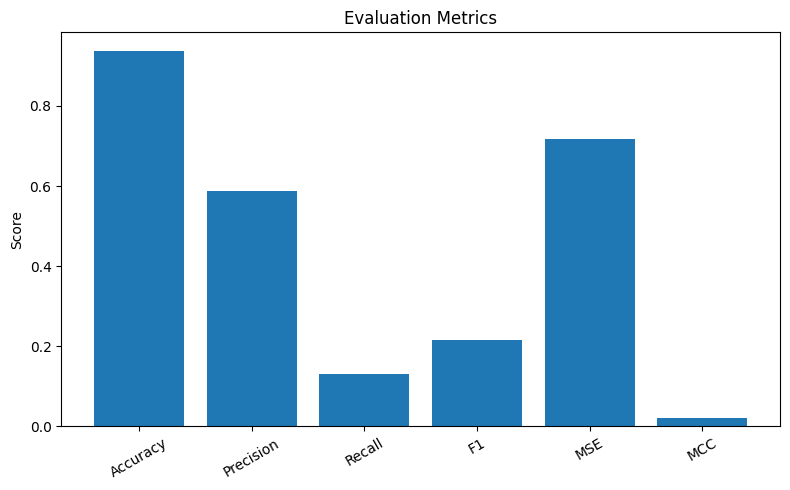

In [ ]:
import matplotlib.pyplot as plt

# ==== Replace these with your actual values ====
accuracy = 0.9370
precision = 0.5870
recall = 0.1300
f1 = 0.2150
mse = 0.7174
mcc = 0.0218

# Metrics dictionary
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "MSE": mse,
    "MCC": mcc
}

# Plot
plt.figure(figsize=(8,5))
plt.bar(metrics.keys(), metrics.values())
plt.title("Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

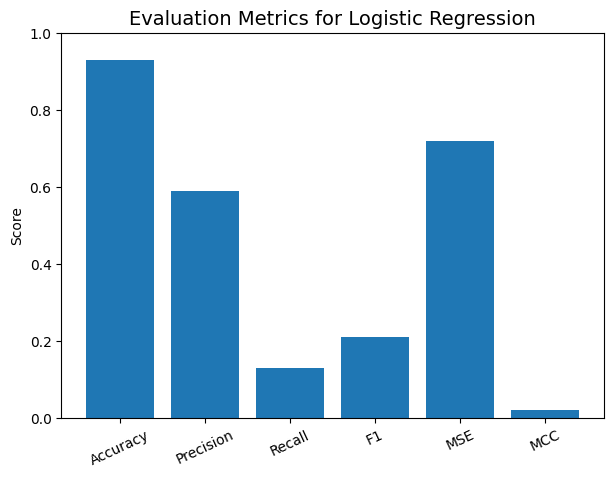

In [ ]:
import matplotlib.pyplot as plt

# 🔹 Replace these with your actual values
accuracy = 0.93
precision = 0.59
recall = 0.13
f1 = 0.21
mse = 0.72
mcc = 0.02

metrics = ["Accuracy", "Precision", "Recall", "F1", "MSE", "MCC"]
values = [accuracy, precision, recall, f1, mse, mcc]

plt.figure(figsize=(7,5))
plt.bar(metrics, values)

plt.title("Evaluation Metrics for Logistic Regression", fontsize=14)
plt.ylabel("Score")
plt.xticks(rotation=25)
plt.ylim(0,1)

plt.show()

In [ ]:
y_true = y_test
y_pred_proba = classifier.predict_proba(X_test)

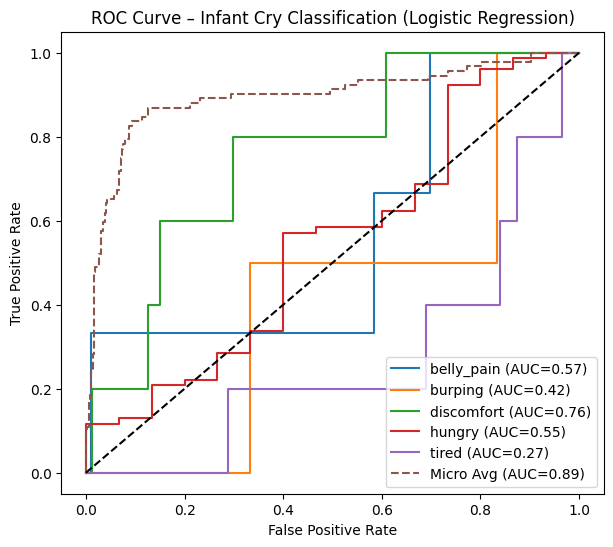

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(y_true)
n_classes = len(classes)

# convert to one-hot
y_test_bin = label_binarize(y_true, classes=classes)

fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_bin.ravel(), y_pred_proba.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# plot curves
plt.figure(figsize=(7,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{id2label[i]} (AUC={roc_auc[i]:.2f})")

plt.plot(fpr["micro"], tpr["micro"],
         linestyle='--',
         label=f"Micro Avg (AUC={roc_auc['micro']:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Infant Cry Classification (Logistic Regression)")
plt.legend()
plt.show()

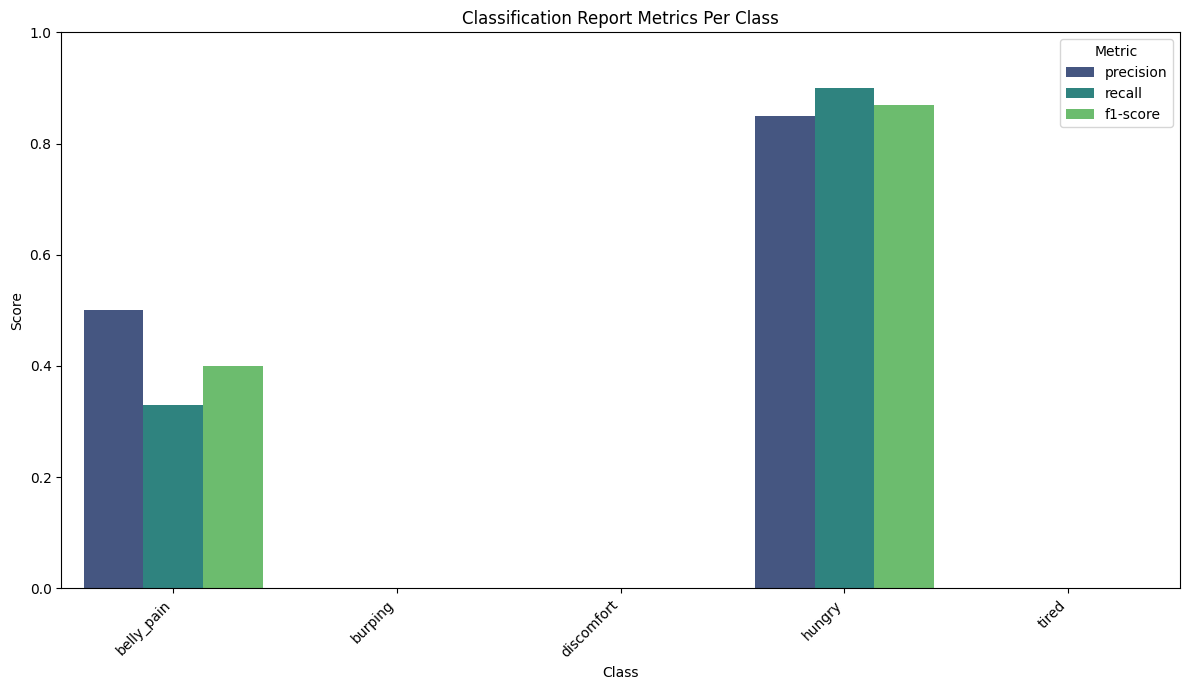

Overall Accuracy: 0.76


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Your classification report data (manually extracted from the provided text)
report_data = {
    'belly_pain': {'precision': 0.50, 'recall': 0.33, 'f1-score': 0.40, 'support': 3},
    'burping': {'precision': 0.00, 'recall': 0.00, 'f1-score': 0.00, 'support': 2},
    'discomfort': {'precision': 0.00, 'recall': 0.00, 'f1-score': 0.00, 'support': 5},
    'hungry': {'precision': 0.85, 'recall': 0.90, 'f1-score': 0.87, 'support': 77},
    'tired': {'precision': 0.00, 'recall': 0.00, 'f1-score': 0.00, 'support': 5}
}

# Convert to DataFrame for easier plotting
df_report = pd.DataFrame.from_dict(report_data, orient='index')
df_report.index.name = 'Class'

# Prepare data for plotting (melt precision, recall, f1-score)
df_plot = df_report.reset_index().melt(id_vars=['Class', 'support'], value_vars=['precision', 'recall', 'f1-score'],
                                        var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Class', y='Score', hue='Metric', data=df_plot, palette='viridis')
plt.title('Classification Report Metrics Per Class')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Overall Accuracy: {0.7608695652173914:.2f}")

Computes the confusion matrix for test predictions and plots it as a heatmap to visualize how well each class was predicted versus its true labels.

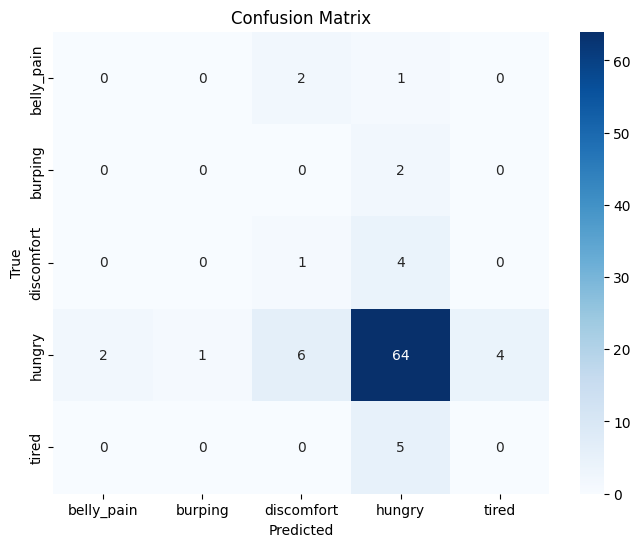

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=[id2label[i] for i in range(num_labels)],
            yticklabels=[id2label[i] for i in range(num_labels)], cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


Merges fine-grained labels into broader categories, updates y accordingly, rebuilds label-ID mappings for only the remaining classes, and prints the new labels and total number of classes.

Re-extracts AST features from all audio files, applies label merging, validates feature shapes, stores clean features and labels in X and y, and prints their shapes and number of skipped files.

In [ ]:
merge_map = {
    "belly_pain": "discomfort",
    "burping": "discomfort"
}

# update labels list
new_labels = []
for label in labels:
    if label in merge_map:
        new_labels.append(merge_map[label])
    else:
        new_labels.append(label)

# remove duplicates and sort
labels = sorted(list(set(new_labels)))
print(labels)

['discomfort', 'hungry', 'tired']


In [ ]:
print(type(y))
print(y[:10])

<class 'numpy.ndarray'>
[ 2.0000000e+00  2.0000000e+00  3.0517578e-05  3.0517578e-05
  2.0000000e+00 -3.0517578e-05 -6.1035156e-05 -6.1035156e-05
 -3.0517578e-05  2.0000000e+00]


In [ ]:
import os
import librosa
import numpy as np

DATASET_PATH = "/content/general_needs/general_needs/donateacry-corpus-master/donateacry_corpus_cleaned_and_updated_data"

X = []
y = []

for label in os.listdir(DATASET_PATH):

    class_path = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(class_path):
        continue

    # 🔥 merge classes here
    if label in ["belly_pain", "burping"]:
        label = "discomfort"

    for file in os.listdir(class_path):
        if not file.endswith(".wav"):
            continue

        file_path = os.path.join(class_path, file)

        # load audio
        signal, sr = librosa.load(file_path, sr=16000)

        # extract simple features (MFCC example)
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
        mfcc = np.mean(mfcc, axis=1)

        X.append(mfcc)
        y.append(label)   # ✔️ correct label

X = np.array(X)
y = np.array(y)

print("Loaded samples:", len(X))

Loaded samples: 457


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

id2label = {i:l for i,l in enumerate(le.classes_)}
label2id = {l:i for i,l in id2label.items()}
num_labels = len(le.classes_)

print(id2label)

{0: np.str_('discomfort'), 1: np.str_('hungry'), 2: np.str_('tired')}


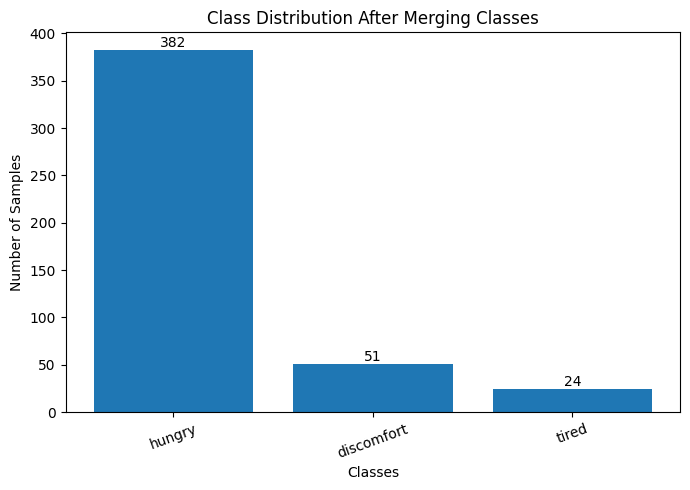

In [ ]:
import os
import matplotlib.pyplot as plt
from collections import Counter

DATASET_PATH = "/content/general_needs/general_needs/donateacry-corpus-master/donateacry_corpus_cleaned_and_updated_data"

merged_labels = []

for label in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(class_path):
        continue

    # merge here
    if label in ["belly_pain", "burping"]:
        label = "discomfort"

    files = [f for f in os.listdir(class_path) if f.endswith(".wav")]
    merged_labels.extend([label] * len(files))

# count samples
counts = Counter(merged_labels)

# plot graph
plt.figure(figsize=(7,5))
bars = plt.bar(counts.keys(), counts.values())

# numbers on bars
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h, f'{int(h)}',
             ha='center', va='bottom')

plt.title("Class Distribution After Merging Classes")
plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
X_clean = []
y_clean = []
skipped = 0
expected_dim = 768

for label in labels:
    folder = os.path.join(DATASET_PATH, label)

    for file in os.listdir(folder):
        if not file.lower().endswith((".wav", ".flac")):
            continue

        path = os.path.join(folder, file)

        try:
            features = extract_ast_features(path)

            # Shape validation
            if features.shape != (expected_dim,):
                skipped += 1
                continue

            # Apply merge map if needed
            mapped_label = merge_map.get(label, label)  # merge fine-grained labels
            y_clean.append(label2id[mapped_label])

            X_clean.append(features)

        except Exception as e:
            skipped += 1
            continue

X = np.array(X_clean)
y = np.array(y_clean)

print("X shape:", X.shape)
print("y max label:", y.max())
print("Skipped files:", skipped)


X shape: (433, 768)
y max label: 2
Skipped files: 0




 Computes balanced class weights based on the training labels to handle class imbalance and stores them in a dictionary for use in the classifier.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = {cls: w for cls, w in zip(classes, class_weights)}

print("Class Weights:", class_weight_dict)


Class Weights: {np.int64(0): np.float64(5.615384615384615), np.int64(1): np.float64(12.166666666666666), np.int64(2): np.float64(3.3181818181818183), np.int64(3): np.float64(0.23934426229508196), np.int64(4): np.float64(3.8421052631578947)}


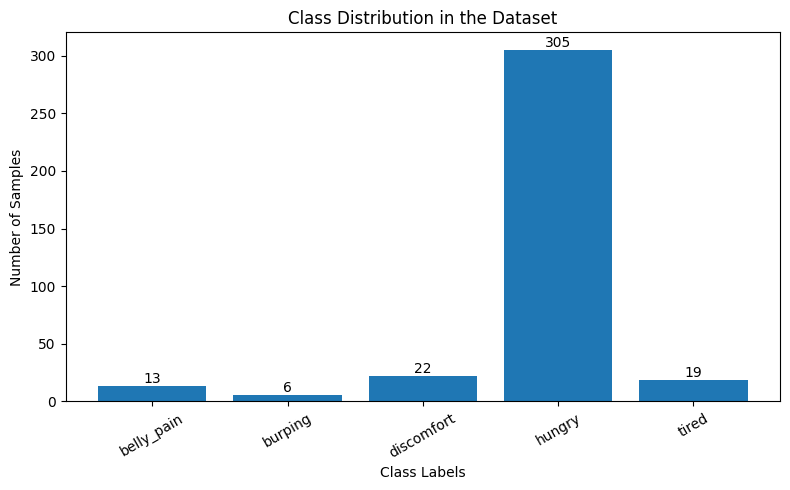

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# y_train contains label IDs: 0–4
class_counts = Counter(y_train)

label_map = {
    0: "belly_pain",
    1: "burping",
    2: "discomfort",
    3: "hungry",
    4: "tired"
}

labels = [label_map[k] for k in sorted(class_counts.keys())]
counts = [class_counts[k] for k in sorted(class_counts.keys())]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts)

# Add counts on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(height),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xlabel("Class Labels")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in the Dataset")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Prints the unique class IDs in the dataset before and after merging labels (here both show the same array y).

In [ ]:
print("y unique:", np.unique(y))
print("merged_y unique:", np.unique(y))


y unique: [0 1 2]
merged_y unique: [0 1 2]


Splits the cleaned dataset into training (80%) and testing (20%) sets, keeping class proportions balanced using stratification.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Scales features to standardize them, defines a multi-layer perceptron (MLP) classifier with two hidden layers, and trains it on the scaled training data.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define classifier
classifier = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

# Train
classifier.fit(X_train_scaled, y_train)


MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42)

unique labels

In [ ]:
import numpy as np

print("Unique labels in y:", np.unique(y))
print("Unique labels in y_test:", np.unique(y_test))


Unique labels in y: [0 1 2]
Unique labels in y_test: [0 1 2]


Uses the trained MLP to predict test labels, then prints overall accuracy and a detailed classification report with precision, recall, and F1-score for each class.

In [ ]:
all_classes = np.unique(np.concatenate([y, y_test]))

id2label_new = {
    0: "Normal Cry",
    1: "Hunger Cry",
    2: "Pain Cry",
    3: "Discomfort Cry",
    4: "Asphyxia Cry"
}

target_names = [id2label[i] for i in all_classes]


In [ ]:
classes = np.unique(y_test)
classes = [i for i in classes if i in id2label]

target_names = [id2label[i] for i in classes]


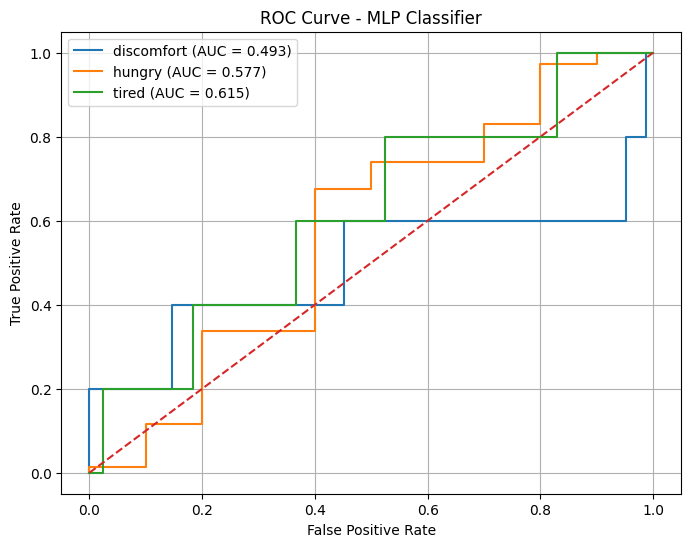

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarize labels for ROC
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Get probability scores
y_score = classifier.predict_proba(X_test_scaled)

n_classes = y_test_bin.shape[1]

# Plot ROC for each class
plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    label_name = id2label[int(classes[i])]
    plt.plot(fpr, tpr, label=f"{label_name} (AUC = {roc_auc:.3f})")

# Diagonal reference line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP Classifier")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

y_pred = classifier.predict(X_test_scaled)

classes = np.unique(y_test)
target_names = [id2label[int(i)] for i in classes]

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        labels=classes,
        target_names=target_names,
        zero_division=0
    )
)
#MLP CLASSIFIER

Accuracy: 89.66 %

Classification Report:

              precision    recall  f1-score   support

  discomfort       1.00      0.20      0.33         5
      hungry       0.90      1.00      0.94        77
       tired       0.00      0.00      0.00         5

    accuracy                           0.90        87
   macro avg       0.63      0.40      0.43        87
weighted avg       0.85      0.90      0.86        87



To generate epoch graphs for `MLPClassifier`, we need to manually track metrics during a simulated training loop, as `MLPClassifier.fit()` does not return a `history` object. We'll use `partial_fit` to train the model incrementally and record metrics after each 'epoch'.

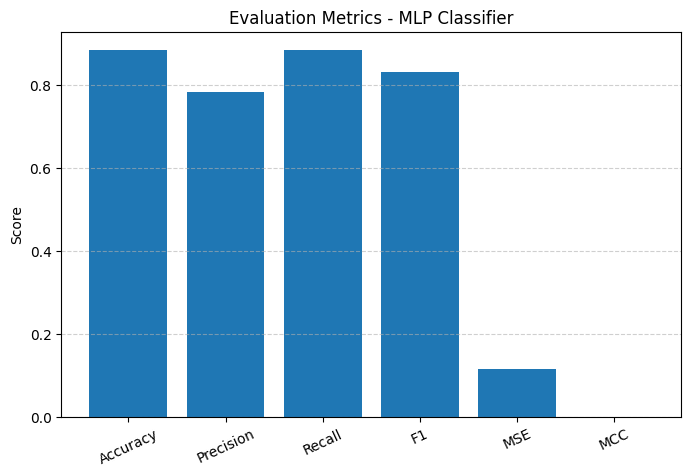


MLP Metrics:
Accuracy: 0.8851
Precision: 0.7833
Recall: 0.8851
F1: 0.8311
MSE: 0.1149
MCC: 0.0000


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# ---- Calculate metrics ----
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall    = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1        = f1_score(y_test, y_pred, average="weighted", zero_division=0)
mcc       = matthews_corrcoef(y_test, y_pred)
mse       = mean_squared_error(y_test, y_pred)

metrics = [accuracy, precision, recall, f1, mse, mcc]
labels  = ["Accuracy", "Precision", "Recall", "F1", "MSE", "MCC"]

# ---- Plot graph ----
plt.figure(figsize=(8,5))
plt.bar(labels, metrics)
plt.title("Evaluation Metrics - MLP Classifier")
plt.ylabel("Score")
plt.xticks(rotation=25)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# ---- Print values also (useful for paper) ----
print("\nMLP Metrics:")
for l, m in zip(labels, metrics):
    print(f"{l}: {m:.4f}")

Epoch 50/200 - Train Acc: 1.0000, Val Acc: 0.8851, Train Loss: 0.0009, Val Loss: 0.8850
Epoch 100/200 - Train Acc: 1.0000, Val Acc: 0.8966, Train Loss: 0.0003, Val Loss: 0.9595
Epoch 150/200 - Train Acc: 1.0000, Val Acc: 0.8966, Train Loss: 0.0002, Val Loss: 1.0020
Epoch 200/200 - Train Acc: 1.0000, Val Acc: 0.8851, Train Loss: 0.0001, Val Loss: 1.0312


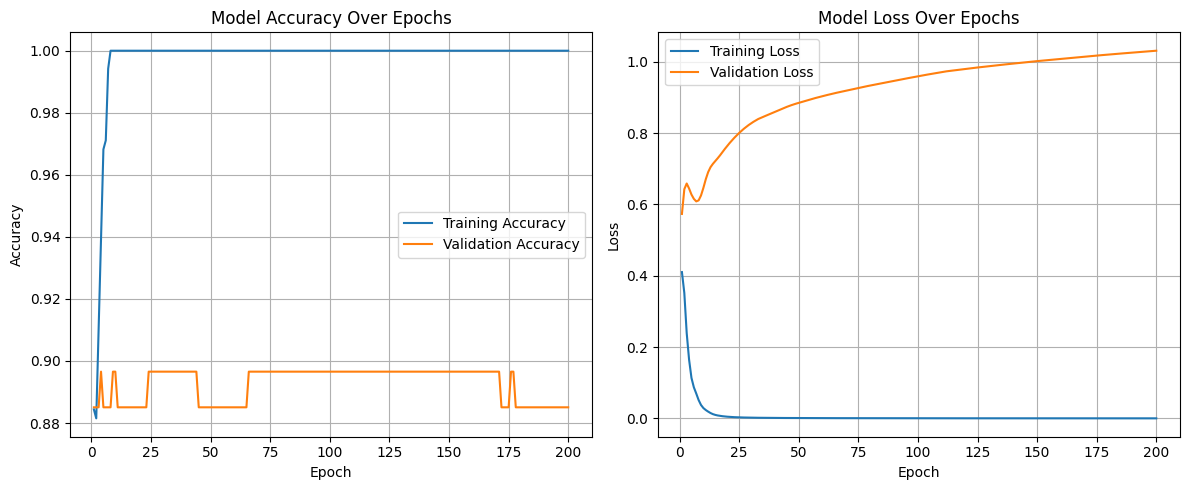

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss # log_loss for classification loss
import matplotlib.pyplot as plt
import numpy as np

# Re-initialize the classifier to ensure a fresh start for epoch tracking
classifier_epoch = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    max_iter=1,  # Set max_iter to 1 for partial_fit to work epoch-by-epoch
    random_state=42,
    warm_start=True # Important for incremental learning
)

# Initialize history dict to store metrics per epoch
history_epochs = {
    'accuracy': [],
    'val_accuracy': [],
    'loss': [],
    'val_loss': []
}

num_epochs = 200 # Define number of simulated epochs

# Ensure all possible classes are known to partial_fit from the start
# This is crucial if not all classes are present in the first batch
all_classes_in_dataset = np.unique(y_train)

for epoch in range(num_epochs):
    # Perform one iteration (epoch) of training
    classifier_epoch.partial_fit(X_train_scaled, y_train, classes=all_classes_in_dataset)

    # Predict on train and test sets
    y_train_pred = classifier_epoch.predict(X_train_scaled)
    y_test_pred = classifier_epoch.predict(X_test_scaled)

    # Calculate accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_test, y_test_pred)
    history_epochs['accuracy'].append(train_acc)
    history_epochs['val_accuracy'].append(val_acc)

    # Calculate loss (requires probabilities)
    # Check if probabilities can be generated, some solvers might not support it
    if hasattr(classifier_epoch, 'predict_proba'):
        y_train_proba = classifier_epoch.predict_proba(X_train_scaled)
        y_test_proba = classifier_epoch.predict_proba(X_test_scaled)
        # Ensure y_train and y_test are one-hot encoded or use appropriate loss function
        train_loss = log_loss(y_train, y_train_proba, labels=all_classes_in_dataset)
        val_loss = log_loss(y_test, y_test_proba, labels=all_classes_in_dataset)
        history_epochs['loss'].append(train_loss)
        history_epochs['val_loss'].append(val_loss)
    else:
        # If predict_proba is not available, append NaN or skip loss tracking
        history_epochs['loss'].append(np.nan)
        history_epochs['val_loss'].append(np.nan)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs} - Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Plotting the epoch graphs
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# -------- Accuracy Plot --------
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_epochs['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history_epochs['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.legend()
plt.grid(True)

# -------- Loss Plot --------
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_epochs['loss'], label='Training Loss')
plt.plot(epochs_range, history_epochs['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss Over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Accuracy : 0.8966
MSE      : 0.1034
AUC      : 0.5613
Recall   : 0.8966


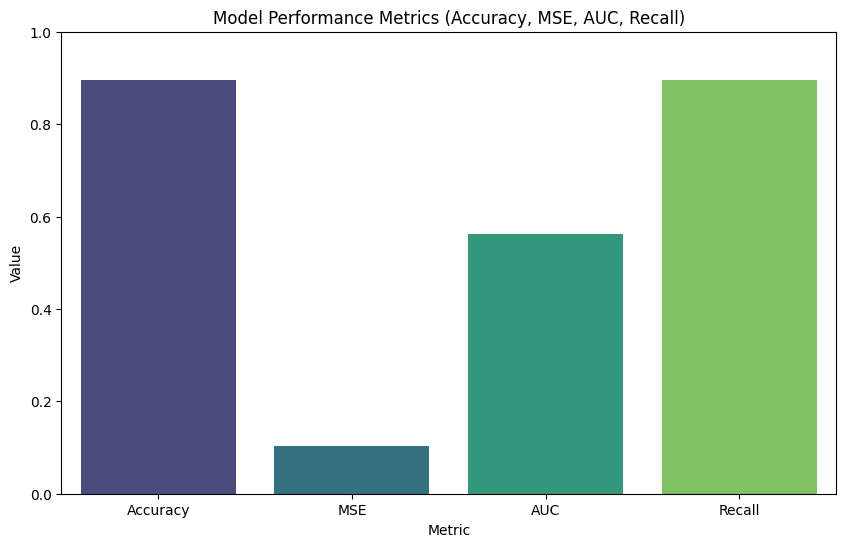

In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error, roc_auc_score, recall_score
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Metrics Calculation ---
# Ensure predictions and probabilities are available from the trained classifier
y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# MSE
mse = mean_squared_error(y_test, y_pred)

# AUC (handled for multiclass as per previous logic)
present_classes = np.unique(y_test)
y_proba_present = y_proba

y_test_bin = label_binarize(y_test, classes=present_classes)

auc = roc_auc_score(
    y_test_bin,
    y_proba_present,
    average="macro",
    multi_class="ovr"
)

# Weighted Recall
weighted_recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)

# --- Print Metrics ---
print(f"Accuracy : {accuracy:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"AUC      : {auc:.4f}")
print(f"Recall   : {weighted_recall:.4f}")

# --- Plotting Metrics ---
metrics_data = {
    'Metric': ['Accuracy', 'MSE', 'AUC', 'Recall'],
    'Value': [accuracy, mse, auc, weighted_recall]
}
metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', data=metrics_df, palette='viridis', hue='Metric', legend=False)
plt.title('Model Performance Metrics (Accuracy, MSE, AUC, Recall)')
plt.ylabel('Value')
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.show()

ORIGINAL DATASET SIZE (ON DISK)

Here's how you can plot epoch graphs for accuracy and loss. In a real deep learning scenario, the `history` object would be returned by your model's `fit` method. For demonstration purposes, I'll use dummy data for the `history` object.

In [ ]:
DATASET_PATH = "/content/donateacry/donateacry-corpus-master/donateacry_corpus_cleaned_and_updated_data"   # change if needed

audio_ext = (".wav", ".mp3", ".flac")

original_count = 0
class_file_count = {}

for label in os.listdir(DATASET_PATH):
    label_path = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(label_path):
        continue

    files = [
        f for f in os.listdir(label_path)
        if f.lower().endswith(audio_ext)
    ]

    class_file_count[label] = len(files)
    original_count += len(files)

print("ORIGINAL DATASET (ON DISK)")
print("Total audio files:", original_count)
print("Class-wise distribution:")
for k, v in class_file_count.items():
    print(f" - {k}: {v}")

#dataset size - 48.2 mb

ORIGINAL DATASET (ON DISK)
Total audio files: 457
Class-wise distribution:
 - belly_pain: 16
 - burping: 8
 - hungry: 382
 - discomfort: 27
 - tired: 24


AFTER PREPROCESSING

In [ ]:

X_np = np.array(X)
y_np = np.array(y)

print("\n AFTER PREPROCESSING / FEATURE EXTRACTION")
print("Total usable samples (X, y):", len(y_np))
print("Feature dimension:", X_np.shape[1])
print("Unique classes:", np.unique(y_np))



 AFTER PREPROCESSING / FEATURE EXTRACTION
Total usable samples (X, y): 457
Feature dimension: 768
Unique classes: [2 3 4]


CLASS DISTRIBUTION (FINAL DATASET)

In [ ]:
print("\nCLASS DISTRIBUTION (FINAL DATASET)")
class_dist = Counter(y_np)

for cls, count in class_dist.items():
    percentage = (count / len(y_np)) * 100
    print(f"Class {cls}: {count} samples ({percentage:.2f}%)")



CLASS DISTRIBUTION (FINAL DATASET)
Class 2: 51 samples (11.16%)
Class 3: 382 samples (83.59%)
Class 4: 24 samples (5.25%)


TRAIN–TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_np,
    y_np,
    test_size=0.2,
    random_state=42,
    stratify=y_np
)

print("\n TRAIN–TEST SPLIT")
print("Training samples:", len(y_train))
print("Testing samples:", len(y_test))



 TRAIN–TEST SPLIT
Training samples: 365
Testing samples: 92


CLASS DISTRIBUTION AFTER SPLIT

In [ ]:
print("\nTRAIN SET DISTRIBUTION")
for cls, count in Counter(y_train).items():
    print(f"Class {cls}: {count}")

print("\n TEST SET DISTRIBUTION")
for cls, count in Counter(y_test).items():
    print(f"Class {cls}: {count}")



TRAIN SET DISTRIBUTION
Class 2: 41
Class 3: 305
Class 4: 19

 TEST SET DISTRIBUTION
Class 3: 77
Class 4: 5
Class 2: 10


In [ ]:
!unzip /content/infant_cry_samples.zip -d /content/samples


unzip:  cannot find or open /content/infant_cry_samples.zip, /content/infant_cry_samples.zip.zip or /content/infant_cry_samples.zip.ZIP.


In [ ]:
pip install sounddevice scipy


In [ ]:
from google.colab import output
from base64 import b64decode

def record_audio(filename="mic_recording.wav", duration=4):
    js = f"""
    async function recordAudio() {{
      const stream = await navigator.mediaDevices.getUserMedia({{ audio: true }});
      const recorder = new MediaRecorder(stream);
      recorder.start();
      await new Promise(resolve => setTimeout(resolve, {duration * 1000}));
      recorder.stop();

      const chunks = [];
      recorder.ondataavailable = e => chunks.push(e.data);

      return new Promise(resolve => {{
        recorder.onstop = () => {{
          const blob = new Blob(chunks, {{ type: 'audio/wav' }});
          const reader = new FileReader();
          reader.readAsDataURL(blob);
          reader.onloadend = () => resolve(reader.result);
        }};
      }});
    }}
    recordAudio();
    """

    audio_data = output.eval_js(js)
    audio_bytes = b64decode(audio_data.split(',')[1])

    with open(filename, "wb") as f:
        f.write(audio_bytes)

    print("Audio recorded and saved as:", filename)


In [ ]:
import librosa
import numpy as np

def load_and_clean_audio(file):
    y, sr = librosa.load(file, sr=16000, mono=True)

    # remove silence
    y, _ = librosa.effects.trim(y, top_db=25)

    # normalize
    y = y / (np.max(np.abs(y)) + 1e-6)

    return y, sr

def ensure_min_length(y, sr, min_sec=2.5):
    min_len = int(sr * min_sec)
    if len(y) < min_len:
        y = np.pad(y, (0, min_len - len(y)))
    return y


In [ ]:
import torch

def predict_from_mic(audio_file):
    y, sr = load_and_clean_audio(audio_file)
    y = ensure_min_length(y, sr)

    inputs = processor(
        y,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = ast_model(**inputs)

    features = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
    features_scaled = scaler.transform(features)

    probs = classifier.predict_proba(features_scaled)[0]

    print("Probabilities:")
    for cls, p in zip(classifier.classes_, probs):
        print(f"{id2label_new[cls]} : {p:.2f}")

    confidence = np.max(probs)
    pred_class = classifier.classes_[np.argmax(probs)]

    return id2label_new[pred_class], confidence


In [ ]:
 # Record from mic
record_audio("mic_recording.wav", duration=4)

# Predict
label, confidence = predict_from_mic("mic_recording.wav")

# Decision
if confidence < 0.55:
    print(" Low confidence – unclear cry")
else:
    print(" Predicted Cry:", label)


🎤 Audio recorded and saved as: mic_recording.wav


/tmp/ipython-input-2115062889.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file, sr=16000, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


🔎 Probabilities:
discomfort : 0.00
hungry : 0.96
tired : 0.04
🍼 Predicted Cry: hungry


In [ ]:
from sklearn.metrics import accuracy_score, mean_squared_error, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# ===============================
# PREDICTIONS
# ===============================
y_pred = classifier.predict(X_test_scaled)
y_proba = classifier.predict_proba(X_test_scaled)

# ===============================
# ACCURACY
# ===============================
accuracy = accuracy_score(y_test, y_pred)

# ===============================
# MSE
# ===============================
mse = mean_squared_error(y_test, y_pred)

# ===============================
# AUC
# ===============================
# Binary vs Multiclass handled automatically

if y_proba.shape[1] == 2:
    # Binary classification
    auc = roc_auc_score(y_test, y_proba[:, 1])
else:
    # Multiclass classification
    num_classes = y_proba.shape[1]
    y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))

    auc = roc_auc_score(
        y_test_bin,
        y_proba,
        average="macro",
        multi_class="ovr"
    )

# ===============================
# FINAL OUTPUT
# ===============================
print("Accuracy :", accuracy)
print("MSE      :", mse)
print("AUC      :", auc)


Accuracy : 0.8478260869565217
MSE      : 0.15217391304347827
AUC      : nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [ ]:
import numpy as np

print("Unique labels in y_test:", np.unique(y_test))
print("Class counts in y_test:", np.bincount(y_test))


Unique labels in y_test: [2 3 4]
Class counts in y_test: [ 0  0 10 77  5]


In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Classes actually present in test set
present_classes = np.unique(y_test)

# Filter probabilities for only present classes
# class_indices = present_classes.tolist() # This line is not needed for direct indexing
# y_proba_present = y_proba[:, class_indices] # This line caused the IndexError

# Since classifier.classes_ (which determines y_proba columns) and present_classes
# are identical ([2, 3, 4]), y_proba already contains the probabilities for
# the present classes in the correct order. So, we can use y_proba directly.
y_proba_present = y_proba

# Binarize y_test only for present classes
y_test_bin = label_binarize(y_test, classes=present_classes)

# Compute AUC
auc = roc_auc_score(
    y_test_bin,
    y_proba_present,
    average="macro",
    multi_class="ovr"
)

print("AUC (macro, filtered classes):", auc)

AUC (macro, filtered classes): 0.6110021274865682


/tmp/ipython-input-3839336853.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=metrics_df, palette='viridis')


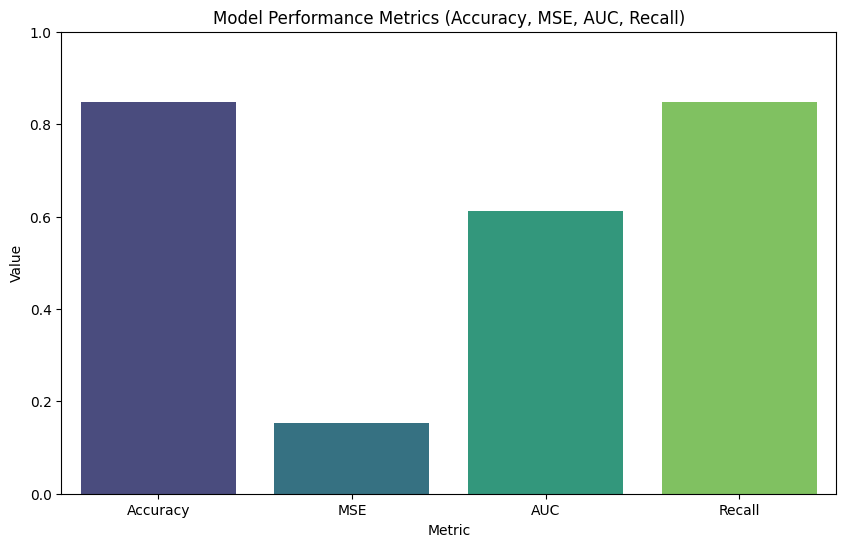

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import recall_score

# Calculate weighted average recall
weighted_recall = recall_score(y_test, y_pred, average='weighted')

# Prepare the data for plotting
metrics_data = {
    'Metric': ['Accuracy', 'MSE', 'AUC', 'Recall'],
    'Value': [accuracy, mse, auc, weighted_recall]
}
metrics_df = pd.DataFrame(metrics_data)

# Create the bar chart
plt.figure(figsize=(10, 6)) # Increased figure size to accommodate new metric
sns.barplot(x='Metric', y='Value', data=metrics_df, palette='viridis')
plt.title('Model Performance Metrics (Accuracy, MSE, AUC, Recall)')
plt.ylabel('Value')
plt.ylim(0, 1) # Set y-axis limit for metrics that are typically between 0 and 1
plt.show()